In [36]:
import os
from getpass import getpass
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import random
from tqdm import tqdm
import copy
from transformers import AutoTokenizer, AutoModel


import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

SEED = 42


In [2]:
# Check to see if files are downloaded before running the following cell
!ls -la data

ls: cannot access 'data': No such file or directory


In [3]:
# Get Kaggle API Token
os.environ['KAGGLE_API_TOKEN'] = getpass("Kaggle API token: ")

# Download kaggle competition datasets
!kaggle competitions download -c llm-classification-finetuning

# Unzip the files
!unzip -q llm-classification-finetuning.zip -d data

# Lists the files
!ls -la data

100% 57.0M/57.0M [00:00<00:00, 166MB/s] 

total 179884
drwxr-xr-x 2 root root      4096 Aug 12 15:45 .
drwxr-xr-x 1 root root      4096 Aug 12 15:45 ..
-rw-r--r-- 1 root root       237 Oct  9  2024 sample_submission.csv
-rw-r--r-- 1 root root     10658 Oct  9  2024 test.csv
-rw-r--r-- 1 root root 184175071 Oct  9  2024 train.csv


# Archetecure of model:

### input variables
```
prompt = prompt
response_1 = either reponse_a or response_b
response_2 = the other response_a/b
```
### Encoding model
```
model_1 = DeBERTA v3 base
```

### Classification model
```
model_2 = classification model
```
### pipeline of data
```
prompt -> model_1 -> output_p
response_1 -> model_1 -> output_1
response_2 -> model_1 -> output_2

(output_p, output_1, output_2) -> model_2 -> (prob of first response, prob of second response, prob of tie)
```



In [4]:
class ResponsePreferenceDataset(Dataset):
    """
    A custom Dataset class for handling prompts, responses from two models, and preference labels.
    This Dataset uses lazy loading.
    """
    def __init__(self, prompts, responses_a, responses_b, labels, tokenizer, max_len=512, prob=0.5):
        """
        Initializes the dataset.

        Args:
            prompts (list): A list of strings containing the prompts.
            responses_a (list): A list of strings containing the responses to
                model_a.
            responses_b (list): A list of strings containing the responses to
                model_b.
            labels (ndarray): A 1-d array of integers containing the preferred
                response.
                - 0: response_a preferred
                - 1: response_b preferred
                - 2: tie
            tokenizer (object): An object used to convert text into numerical
                indices.
            max_len (int): The maximum sequence length allowed for each
                prompt/response.
            prob (float): The probability (between 0 and 1) of permuting the
                order of responses.
        """
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.prob = prob
        self.prompts = prompts
        self.responses_a = responses_a
        self.responses_b = responses_b
        self.labels = labels

    def __len__(self):
        """
        Returns the number of samples in the dataset.

        Returns:
            int: The number of samples in the dataset.
        """
        return len(self.prompts)

    def __getitem__(self, idx):
        """
        Retrieves and tokenizes one sample, randomly swaps response_a/b (with
            probability self.prob) to reduce positional bias in training.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            dict: A dictionary containing:
                - prompt (Tensor): Token IDs for the prompt.
                - prompt_mask (Tensor): Attention mask for the prompt.
                - response_0 (Tensor): Token IDs for response_a (possibly
                    swapped).
                - response_0_mask (Tensor): Attention mask for response_0.
                - response_1 (Tensor): Token IDs for response_b (possibly
                    swapped).
                - response_1_mask (Tensor): Attention mask for response_1.
                - label (Tensor): Integer class label 0/1/2,
                    adjusted if swapped.
        """
        prompt = self.prompts[idx]
        label = self.labels[idx]
        response_a = self.responses_a[idx]
        response_b = self.responses_b[idx]

        # Swap responses and adjust label with probability self.prob.
        if random.random() < self.prob:
            response_a, response_b = response_b, response_a
            if label == 0:
                label = 1
            elif label ==1:
                label = 0

        # Switch from response_a/response_b to response_0/response_1 since
        # response_a and response_b may have been swapped.

        response_0, response_1 = response_a, response_b

        encoded_p = self.tokenizer(prompt, max_length=self.max_len,
                                   truncation=True, padding="max_length",
                                   return_tensors="pt")
        encoded_0 = self.tokenizer(response_0, max_length=self.max_len,
                                   truncation=True, padding="max_length",
                                   return_tensors="pt")
        encoded_1 = self.tokenizer(response_1, max_length=self.max_len,
                                   truncation=True, padding="max_length",
                                   return_tensors="pt")

        # After retrieving the tokens, we remove the extra dimension that was added
        # by the tokenizer (the batch dim) even for a single string.
        prompt = encoded_p["input_ids"].squeeze(0)
        response_0 = encoded_0["input_ids"].squeeze(0)
        response_1 = encoded_1["input_ids"].squeeze(0)

        prompt_mask = encoded_p["attention_mask"].squeeze(0)
        response_0_mask = encoded_0["attention_mask"].squeeze(0)
        response_1_mask = encoded_1["attention_mask"].squeeze(0)

        label = torch.tensor(label, dtype=torch.long)

        return {
            "prompt": prompt, "prompt_mask": prompt_mask,
            "response_0": response_0, "response_0_mask": response_0_mask,
            "response_1": response_1, "response_1_mask": response_1_mask,
            "label": label,
            "idx": idx
        }




In [5]:

df = pd.read_csv("data/train.csv")
#df = df.head(200)

# Convert one hot to 0,1,2
labels_one_hot = df[["winner_model_a","winner_model_b","winner_tie"]]
labels = labels_one_hot.values.argmax(axis = 1)


In [6]:


tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-small")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

In [7]:
train_df, val_df, train_labels, val_labels = train_test_split(
    df,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

val_df, test_df, val_labels, test_labels = train_test_split(
    val_df,
    val_labels,
    test_size=0.5,
    stratify=val_labels,
    random_state=SEED
)

In [8]:
full_dataset = ResponsePreferenceDataset(
    prompts=df["prompt"].tolist(),
    responses_a=df["response_a"].tolist(),
    responses_b=df["response_b"].tolist(),
    labels=labels,
    tokenizer=tokenizer,
    prob=0
)

train_dataset = ResponsePreferenceDataset(
    prompts = train_df["prompt"].tolist(),
    responses_a = train_df["response_a"].tolist(),
    responses_b = train_df["response_b"].tolist(),
    labels= train_labels,
    tokenizer = tokenizer
)
val_dataset = ResponsePreferenceDataset(
    prompts = val_df["prompt"].tolist(),
    responses_a = val_df["response_a"].tolist(),
    responses_b = val_df["response_b"].tolist(),
    labels= val_labels,
    tokenizer = tokenizer,
    prob=0
)
test_dataset = ResponsePreferenceDataset(
    prompts = test_df["prompt"].tolist(),
    responses_a = test_df["response_a"].tolist(),
    responses_b = test_df["response_b"].tolist(),
    labels= test_labels,
    tokenizer = tokenizer,
    prob=0
)

In [9]:
batch_size = 64
full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
train_loader = DataLoader( train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader( val_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader( test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [10]:
class PreferenceClassifier(nn.Module):
    """
    Classification head that takes pooled encoder representations of the prompt,
    response_0, and response_1 and predicts which response is preferred:
        - 0 response_0 preferred
        - 1 response_1 preferred
        - 2 tie
    """
    def __init__(self, hidden_state=768, num_classes=3):
        """
        Initializes the classifier.

        Args:
            - hidden_state (int): The dimension of the encoding of each text.
            - num_classes (int): The number of classes.
        """
        super().__init__()
        self.fc1 = nn.Linear(hidden_state*3, hidden_state)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(hidden_state, num_classes)

    def forward(self, output_p, output_0, output_1):
        """
        Executes the forward pass of the model to generate classification
        logits.

        Args:
            - output_p (Tensor): Encoded prompt.
            - output_0 (Tensor): Encoded response_0.
            - output_1 (Tensor): Encoded response_1.

        Returns:
            Tensor: Classification logits.
        """
        combined = torch.cat([output_p, output_0, output_1], dim=1)
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.fc2(x)

        return logits


In [11]:
class PreferenceModel(nn.Module):
    """
    A model that takes the encoder model and the classifier
    model to create the full end-to-end model. The model first encodes prompt,
    response_0, response_1 through the encoder model. The three outputs are fed
    through the classifier model to predict the user preference:
        - 0: response_0 is preferred
        - 1: response_1 is preferred
        - 2: tie
    """
    def __init__(self, model_encoder, model_classifier):
        """
        Initializes the model with the model encoder and model classifier.

        Args:
            model_encoder (nn.Module): A pretrained encoder model
                (e.g. DebertaV2Model) that outputs last_hidden_state given
                input_ids and attention_mask.
            model_classifier (PreferenceClassifier): The classification head
                that takes encoder outputs and predicts preference.
        """
        super().__init__()
        self.model_encoder = model_encoder
        self.model_classifier = model_classifier

    def forward(self,prompt, prompt_mask, response_0, response_0_mask, response_1, response_1_mask):
        """
        Executes the forward pass of the model.

        Args:
            prompt (Tensor): The Input tensor containing token indices of
                prompt.
            prompt_mask (Tensor): Attention mask for the prompt.
            response_0 (Tensor): The Input tensor containing token indices of
                response 0.
            response_0_mask (Tensor): Attention mask for response 0.
            response_1 (Tensor): The Input tensor containing token indices of
                response 1.
            response_1_mask (Tensor): Attention mask for response 1.

        Returns:
            Tensor: Classifier logits.
        """
        output_p = self.model_encoder(input_ids=prompt, attention_mask=prompt_mask).last_hidden_state[:,0,:]
        output_0 = self.model_encoder(input_ids=response_0, attention_mask=response_0_mask).last_hidden_state[:,0,:]
        output_1 = self.model_encoder(input_ids=response_1, attention_mask=response_1_mask).last_hidden_state[:,0,:]

        logits = self.model_classifier(output_p, output_0, output_1)

        return logits



In [30]:
# Testing PreferenceModel:
model_encoder = AutoModel.from_pretrained("microsoft/deberta-v3-small", torch_dtype=torch.float32)
model_classifier =PreferenceClassifier()
model = PreferenceModel(model_encoder,model_classifier)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
from google.colab import drive
drive.mount('/content/drive')

path = "MyDrive/Colab Notebooks/LLM Classification Finetuning"

import os
fullpath = os. path.join('/content/drive', path)
print(fullpath)
print(os.path.exists(fullpath))


Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/LLM Classification Finetuning
True


In [15]:
for file in os.listdir(fullpath):
    print(file)

encoded_filename = os.path.join(fullpath,"encoded_full.pt")
cache = torch.load(encoded_filename)
encoded_p, encoded_0, encoded_1, labels = cache["prompt"], cache["response_0"], cache["response_1"], cache["label"]

test.text
test.txt
llm-classification-finetuning
encoded_full.pt


In [16]:
class EncodedPreferenceDataset(Dataset):
    """
    A custom Dataset class for classifier-only training. The class handling
    encoded prompts, responses from two models, and preference labels.
    """
    def __init__(self, prompts, responses_a, responses_b, labels, indices,
                 prob=0.5):
        """
        Initializes the dataset.

        Args:
            prompts (Tensor): A tensor containing the encoded prompts.
            responses_a (Tensor): A tensor containing the encoded
                responses_a's.
            responses_b (Tensor): A tensor containing the encoded
                responses_b's.
            labels (Tensor): A tensor of integers containing the preferred
                response.
                - 0: response_a preferred
                - 1: response_b preferred
                - 2: tie
            indices (ndarray): Array of integer row positions into the full
                precomputed tensors, e.g. train_df.index.values.
            prob (float): The probability (between 0 and 1) of permuting the
                order of responses.
        """
        self.indices = indices
        self.prob = prob
        self.encoded_p = prompts
        self.encoded_a = responses_a
        self.encoded_b = responses_b
        self.labels = labels

    def __len__(self):
        """
        Returns the number of samples in the dataset.

        Returns:
            int: The number of samples in the dataset.
        """
        return len(self.indices)

    def __getitem__(self, idx):
        """
        Retrieves one sample and randomly swaps response_a/b (with
            probability self.prob) to reduce positional bias in training.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            dict: A dictionary containing:
                - encoded_p (Tensor): A tensor containing encoded prompts.
                - encoded_0 (Tensor): A tensor containing encoded response_a
                    (possibly swapped with response_b).
                - encoded_1 (Tensor): A tensor containing encoded response_b
                    (possibly swapped with response_a).
                - label (Tensor): Integer class label 0/1/2,
                    adjusted if swapped.
        """
        row = self.indices[idx]

        # Rename a/b -> 0/1 now, since the block below may swap them.
        encoded_p = self.encoded_p[row]
        encoded_0 = self.encoded_a[row]
        encoded_1 = self.encoded_b[row]
        label = self.labels[row]

        # Swap responses and adjust label with probability self.prob.
        if random.random() < self.prob:
            encoded_0, encoded_1 = encoded_1, encoded_0
            if label == 0:
                label = 1
                label = torch.tensor(label)
            elif label == 1:
                label = 0
                label = torch.tensor(label)

        return {
            "encoded_p": encoded_p,
            "encoded_0": encoded_0,
            "encoded_1": encoded_1,
            "label": label
            }




In [17]:

train_dataset = EncodedPreferenceDataset(
    prompts=encoded_p,
    responses_a=encoded_0,
    responses_b=encoded_1,
    labels=labels,
    indices=train_df.index.values
)
val_dataset = EncodedPreferenceDataset(
    prompts=encoded_p,
    responses_a=encoded_0,
    responses_b=encoded_1,
    labels=labels,
    indices=val_df.index.values,
    prob=0
)
test_dataset = EncodedPreferenceDataset(
    prompts=encoded_p,
    responses_a=encoded_0,
    responses_b=encoded_1,
    labels=labels,
    indices=test_df.index.values,
    prob=0
)

In [18]:
batch_size = 64
train_loader = DataLoader( train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader( val_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader( test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [19]:
def preprocess_input():
    # Preproccess input through encoder:
    device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
    model_encoder = model_encoder.to(device)
    print(f"Encoding using device: {device}")
    model_encoder.eval()

    hidden_size = model_encoder.config.hidden_size
    num_samples = len(full_dataset)

    encoded_p = torch.zeros(num_samples, hidden_size)
    encoded_0 = torch.zeros(num_samples, hidden_size)
    encoded_1 = torch.zeros(num_samples, hidden_size)

    with torch.no_grad():
        for batch in tqdm(full_loader):
            idx = batch["idx"]
            batch = {k: v.to(device) for k,v in batch.items() if k != "idx"}
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                output_p = model_encoder(input_ids=batch["prompt"], attention_mask=batch["prompt_mask"]).last_hidden_state[:,0,:]
                output_0 = model_encoder(input_ids=batch["response_0"], attention_mask=batch["response_0_mask"]).last_hidden_state[:,0,:]
                output_1 = model_encoder(input_ids=batch["response_1"], attention_mask=batch["response_1_mask"]).last_hidden_state[:,0,:]
            encoded_p[idx] = output_p.float().cpu()
            encoded_0[idx] = output_0.float().cpu()
            encoded_1[idx] = output_1.float().cpu()

    print("Saving...")
    filename = os.path.join(fullpath,"encoded_full.pt")
    torch.save(
        {"prompt": encoded_p, "response_0": encoded_0, "response_1": encoded_1, "label": torch.tensor(labels)},
        filename
    )

    print("Saved file")

In [ ]:
# Evaluate ntrained model with pre-encoded input
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
model_classifier = model_classifier.to(device)


print(f"Evaluating untrained model using device: {device}")
model_classifier.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in tqdm(train_loader):
        batch = {k: v.to(device) for k,v in batch.items()}
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            output = model_classifier(
                batch["encoded_p"], batch["encoded_0"],
                batch["encoded_1"]
            )
        predicted = torch.argmax(output, 1)
        total += batch["label"].size(0)
        correct += (predicted == batch["label"]).sum().item()
acc = 100 * correct / total
print(f"Intitial test accuracy before training: {acc}")

Evaluating untrained model using device: cuda


100%|██████████| 719/719 [00:03<00:00, 186.22it/s]

Intitial test accuracy before training: 43.67456123181314


### Intial run. Time with calling encoder 3 separate times:
100%|██████████| 180/180 [13:00<00:00,  4.34s/it]
Intitial test accuracy before training: 30.880306193458594

Note:
- adding workers didn't speed up time
- changed from calling encoder 3 times into one time by stacking into one big batch. Didn't improve by much (30 seconds per batch)
- Considered changing max_len on token lengths, but stats on data shows we would lose too much info:

prompt: mean=101.0, median=27,  95th=377, 99th=1390, max=9358
response_a: mean=347.0, median=264,  95th=963, 99th=1961, max=9557
response_b: mean=350.6, median=266,  95th=960, 99th=2014, max=15685

Note:
 - Tried mixed precision and got:
 100%|██████████| 180/180 [05:35<00:00,  1.87s/it]Intitial test accuracy before training: 34.8990953375087
 - Mixed precission and "small" version of model:
 100%|██████████| 180/180 [02:39<00:00,  1.13it/s]Intitial test accuracy before training: 30.897703549060545
 - Mixed precission and "xsmall":
 100%|██████████| 180/180 [02:37<00:00,  1.14it/s]Intitial test accuracy before training: 34.49895615866388

In [31]:
model = model_classifier

loss = nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

In [32]:
# Train one epoch:

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")


def train_epoch(model, loader, device, optimizer, loss):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader, leave=False):
        batch = {k:v.to(device) for k,v in batch.items()}

        optimizer.zero_grad()
        output = model(batch["encoded_p"], batch["encoded_0"],
                                batch["encoded_1"])
        batch_loss = loss(output, batch["label"])
        batch_loss.backward()
        optimizer.step()

        running_loss += batch_loss.item() * batch["label"].size(0)
        predicted = torch.argmax(output,1)
        total += batch["label"].size(0)
        correct += (predicted == batch["label"]).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = (correct/ total) * 100

    return epoch_loss, epoch_acc

def validate_epoch(model, loader, device, optimizer, loss):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader, leave=False):
        batch = {k:v.to(device) for k,v in batch.items()}

        output = model(batch["encoded_p"], batch["encoded_0"],
                                batch["encoded_1"])
        batch_loss = loss(output, batch["label"])



        running_loss += batch_loss.item() * batch["label"].size(0)
        predicted = torch.argmax(output,1)
        total += batch["label"].size(0)
        correct += (predicted == batch["label"]).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = (correct/ total) * 100

    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, device, optimizer, loss, num_epochs):

    loss_train_history = []
    acc_train_history = []
    loss_val_history = []
    acc_val_history = []

    best_model = copy.deepcopy(model)
    best_acc = 0.0

    print(f"Training on device {device} for {num_epochs} epochs:")
    model = model.to(device)
    epoch_bar = tqdm(range(num_epochs), desc="Epochs")
    for epoch in epoch_bar:
        epoch_train_loss, epoch_train_acc = train_epoch(model, train_loader, device, optimizer, loss)
        loss_train_history.append(epoch_train_loss)
        acc_train_history.append(epoch_train_acc)

        epoch_val_loss, epoch_val_acc = validate_epoch(model, val_loader, device, optimizer, loss)
        loss_val_history.append(epoch_val_loss)
        acc_val_history.append(epoch_val_acc)

        epoch_bar.set_description(f"Epoch {epoch+1} | Train loss: {epoch_train_loss:.4f} acc: {epoch_train_acc:.2f}%"
                                  f"| Val loss: {epoch_val_loss:.4f} acc: {epoch_val_acc:.2f}%")
        if epoch_val_acc > best_acc:
            best_model = copy.deepcopy(model)
            best_acc = epoch_val_acc
    print(f"Training Complete. Best Val ACC: {best_acc}")

    return {
        "loss_train_history": loss_train_history,
        "acc_train_history": acc_train_history,
        "loss_val_history": loss_val_history,
        "acc_val_history": acc_val_history,
        "best_acc": best_acc,
        "best_model": best_model
    }




In [33]:
results = train_model(model, train_loader, val_loader, device, optimizer, loss, num_epochs=30)

Training on device cuda for 30 epochs:


Epoch 30 | Train loss: 1.0487 acc: 45.18%| Val loss: 1.0475 acc: 44.95%: 100%|██████████| 30/30 [02:41<00:00,  5.38s/it]

Training Complete. Best Val ACC: 46.363952679192764


In [34]:
filename = f"model_classifier Val Acc {results["best_acc"]}.pt"
torch.save(
    results["best_model"].state_dict(),
    os.path.join(fullpath,filename)
)


In [29]:
model_classifier = PreferenceClassifier()
model_classifier.load_state_dict(torch.load(os.path.join(fullpath,filename)))

<All keys matched successfully>

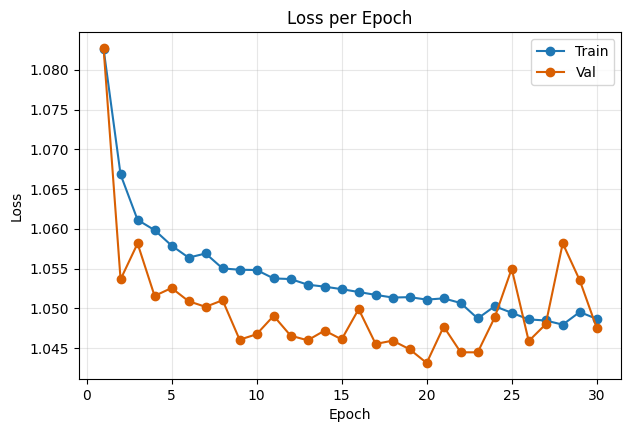

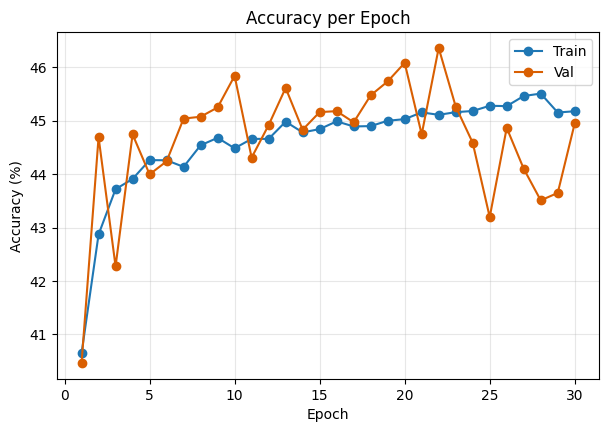

In [37]:
import matplotlib.pyplot as plt

epochs = range(1, len(results["loss_train_history"]) + 1)

# Loss
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(epochs, results["loss_train_history"], marker="o", color="#1f77b4", label="Train")
ax.plot(epochs, results["loss_val_history"], marker="o", color="#d95f02", label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss per Epoch")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# Accuracy
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(epochs, results["acc_train_history"], marker="o", color="#1f77b4", label="Train")
ax.plot(epochs, results["acc_val_history"], marker="o", color="#d95f02", label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy per Epoch")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
